# Uniqueness of festival lineups

This notebook compares the similarity of a given festival's lineup with those of other festivals.

Similarity is computed using the [Jaccard Similarity Index](https://www.ibm.com/think/topics/jaccard-similarity), which measures how many elements (artists) are shared between two sets (lineups), normalized to their size. A Jaccard similarity of 0 means there is are no shared elements, and 1 means a full match between the two sets.

In [1]:
import re
import pandas as pd
from festival_analysis.analysis_utils import query_db, jaccard_similarity
from itertools import combinations, zip_longest
import seaborn as sns
from matplotlib import pyplot as plt
from tabulate import tabulate

pd.options.display.float_format = "{:,.2f}".format

## Data pull

In [2]:
query_lineups = """
SELECT
  festival_id||'-'||edition_year||'-'||artist_id AS entry_id,
  CAST(festival_id AS VARCHAR) AS festival_id,
  festival_id||'-'||edition_year AS edition_id,
  festival_name,
  size_band,
  edition_year,
  location_country,
  CAST(artist_id AS VARCHAR) AS artist_id,
  display_name,
  artist_country,
  ra_status
FROM
  edition_lineups
-- Look onwards from 2015 without lockdown years
WHERE 
  edition_year >= 2015 
  AND edition_year NOT IN (2020, 2021)
"""

df_lineups = query_db(query_lineups, index="entry_id")

## Housekeeping

Create mappings and functions to make later analysis easy and tidy.

In [3]:
df_festival_stats = df_lineups.groupby("festival_id").agg(
    {
        "festival_name": pd.Series.mode,
        "size_band": pd.Series.mode,
        "location_country": pd.Series.mode,
    }
)
df_festival_stats

,festival_name,size_band,location_country
festival_id,,,
1082689011160469009,Naturalis,1 - XS,IT
1199349725585256505,Botanica,1 - XS,SE
1311579144894607994,Baltic Weekender,2 - S,GB
1336484889209428545,Accidental Meetings,1 - XS,GB
1457418356257237432,De Weide,1 - XS,NL
...,...,...,...
8868442761932147185,Lentekabinet,2 - S,NL
8969544748426605587,Lighthouse,2 - S,HR
8982369933757010704,Horst,3 - M,BE


In [4]:
festival_name_map = df_festival_stats["festival_name"].to_dict()
festival_id_map = {v: k for k, v in festival_name_map.items()}
artist_name_map = (
    df_lineups[["artist_id", "display_name"]]
    .set_index("artist_id")["display_name"]
    .to_dict()
)

In [5]:
n_festivals = 50
top_n_festivals = (
    df_lineups.groupby("festival_id")
    .size()
    .sort_values(ascending=False)[:n_festivals]
    .index
)

In [6]:
n_artists = 500
top_n_artists = (
    df_lineups.groupby("artist_id")
    .size()
    .sort_values(ascending=False)[:n_artists]
    .index
)

In [7]:
def festival_similarity(fid1: str, fid2: str, df_lineups: pd.DataFrame) -> tuple:
    """Compute the Jaccard similarity of two festivals (every edition of each)."""
    artists1 = set(df_lineups[df_lineups["festival_id"] == fid1]["artist_id"])
    artists2 = set(df_lineups[df_lineups["festival_id"] == fid2]["artist_id"])
    jaccard = jaccard_similarity(artists1, artists2)
    return (fid1, fid2, jaccard)


def build_df_similarities(
    df_lineups: pd.DataFrame, df_festival_stats: pd.DataFrame
) -> pd.DataFrame:
    """Create a matrix of all festival similarities."""
    festival_pairs = combinations(df_lineups["festival_id"].unique(), 2)
    similarity_results = [
        festival_similarity(fid1, fid2, df_lineups=df_lineups)
        for fid1, fid2 in festival_pairs
    ]
    df_similarities = pd.DataFrame(
        similarity_results,
        columns=["festival_id1", "festival_id2", "jaccard_similarity"],
    )
    df_similarities = df_similarities.merge(
        df_festival_stats.add_suffix("1"),
        how="left",
        left_on="festival_id1",
        right_index=True,
    )
    df_similarities = df_similarities.merge(
        df_festival_stats.add_suffix("2"),
        how="left",
        left_on="festival_id2",
        right_index=True,
    )
    return df_similarities


def festival_edition_similarity(
    fe_id1: str, fe_id2: str, df_lineups: pd.DataFrame
) -> tuple:
    """Compute the Jaccard similarity of two festival editions."""
    artists1 = set(df_lineups[df_lineups["edition_id"] == fe_id1]["artist_id"])
    artists2 = set(df_lineups[df_lineups["edition_id"] == fe_id2]["artist_id"])
    jaccard = jaccard_similarity(artists1, artists2)
    return (fe_id1, fe_id2, jaccard)


def show_similarity(
    id1: str,
    id2: str,
    df_lineups: pd.DataFrame,
    festival_name_map: dict,
    artist_name_map: dict,
) -> None:
    """Print a summary of the similarity of either:
    - two festivals (every edition of each)
    - two festival editions

    This split is inferred from the ending of each ID (edition IDs end with a year e.g. "-2016").
    """
    id1_is_edition = re.search(r"-\d{4}$", id1)
    id2_is_edition = re.search(r"-\d{4}$", id2)

    if id1_is_edition and id2_is_edition:
        id_col = "edition_id"
        name1 = f"{festival_name_map[id1[:-5]]}-{id1[-4:]}"
        name2 = f"{festival_name_map[id2[:-5]]}-{id2[-4:]}"
        similarity_function = festival_edition_similarity
    elif not id1_is_edition and not id2_is_edition:
        id_col = "festival_id"
        name1 = festival_name_map[id1]
        name2 = festival_name_map[id2]
        similarity_function = festival_similarity
    else:
        raise ValueError(
            "Both given IDs must be either editions or festivals, no mixing."
        )

    artists_1 = set(df_lineups[df_lineups[id_col] == id1]["artist_id"])
    artists_2 = set(df_lineups[df_lineups[id_col] == id2]["artist_id"])

    intersection = artists_1.intersection(artists_2)
    only1 = artists_1.difference(artists_2)
    only2 = artists_2.difference(artists_1)
    jaccard_similarity = similarity_function(id1, id2, df_lineups)[2]

    print(f"Similarity report between {id1} - {name1} and {id2} - {name2}")
    print(f"Jaccard similarity: {jaccard_similarity:.2f}")
    print(
        f"{len(intersection)} artists playing at both, {len(only1)} playing only at {name1}, {len(only2)} playing only at {name2}"
    )
    table = list(
        zip_longest(
            [artist_name_map[aid] for aid in intersection],
            [artist_name_map[aid] for aid in only1],
            [artist_name_map[aid] for aid in only2],
            fillvalue="",
        )
    )
    print(
        tabulate(
            table,
            headers=[
                "Intersection",
                f"Playing only at {name1}",
                f"Playing only at {name2}",
            ],
        )
    )

## Analysis

In [8]:
# Save time by just computing similarities across the top few hundred artists
df_lineups = df_lineups[df_lineups["artist_id"].isin(top_n_artists)]

In [9]:
# Create matrix of similarities across all festivals.
df_similarities = build_df_similarities(
    df_lineups=df_lineups, df_festival_stats=df_festival_stats
)

What does the similarity look like across the entire dataset of ~140 festivals?

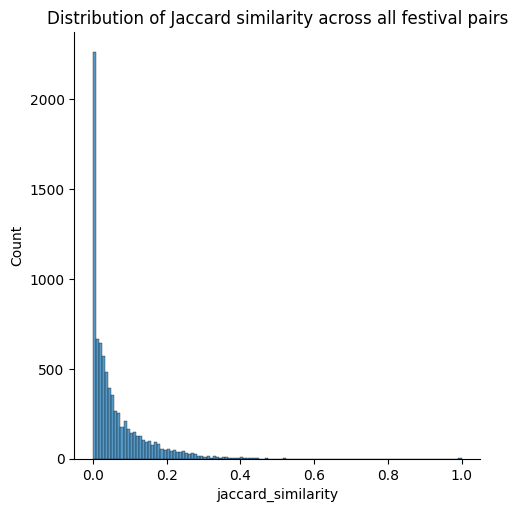

In [10]:
sns.displot(df_similarities["jaccard_similarity"])
plt.title("Distribution of Jaccard similarity across all festival pairs")
plt.show()

In [11]:
mean_similarities = df_similarities.groupby("festival_id1")["jaccard_similarity"].mean()
print(f"Average Jaccard similarity: {mean_similarities.mean():.2f}")

Average Jaccard similarity: 0.05


In general, festivals are pretty unique across the whole dataset. What if we filter for big festivals only?

In [12]:
df_similarities_top_n_festivals = df_similarities[
    (df_similarities["festival_id1"].isin(top_n_festivals))
    & (df_similarities["festival_id2"].isin(top_n_festivals))
]

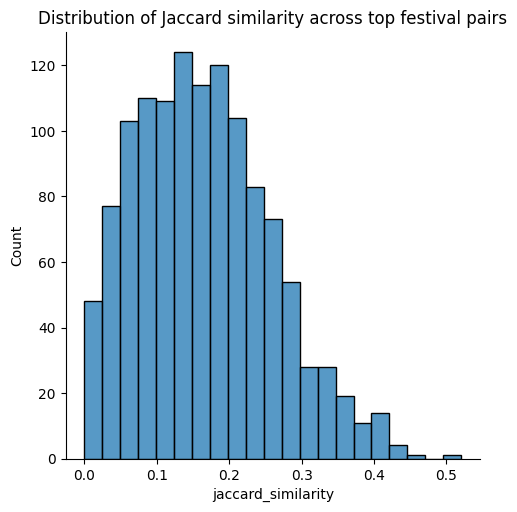

In [13]:
sns.displot(df_similarities_top_n_festivals["jaccard_similarity"])
plt.title("Distribution of Jaccard similarity across top festival pairs")
plt.show()

In [14]:
mean_similarities = df_similarities_top_n_festivals.groupby("festival_id1")[
    "jaccard_similarity"
].mean()
print(f"Average Jaccard similarity: {mean_similarities.mean():.2f}")

Average Jaccard similarity: 0.16


Sharp increase in average Jaccard similarity when filtering for larger festivals.
Let's look at some individual examples. 

In [15]:
df_similarities_top_n_festivals.sort_values("jaccard_similarity", ascending=False).head(
    30
)[["festival_name1", "festival_name2", "jaccard_similarity"]]

,festival_name1,festival_name2,jaccard_similarity
3300,Draaimolen,Dekmantel,0.52
4888,Dimensions,Houghton,0.45
272,Love International,Gala,0.44
904,Brunch Electronik,DGTL,0.43
5278,Horst,Dekmantel,0.43
4893,Dimensions,Dekmantel,0.42
4731,Soundit,Horst,0.42
2800,Drift,Dekmantel,0.42
4650,DGTL,Dekmantel,0.41
4975,Houghton,Gottwood,0.41


In [16]:
show_similarity(
    festival_id_map["Horst"],
    festival_id_map["Dekmantel"],
    df_lineups=df_lineups,
    festival_name_map=festival_name_map,
    artist_name_map=artist_name_map,
)

Similarity report between 8982369933757010704 - Horst and 8578965883151947907 - Dekmantel
Jaccard similarity: 0.43
139 artists playing at both, 65 playing only at Horst, 119 playing only at Dekmantel
Intersection              Playing only at Horst    Playing only at Dekmantel
------------------------  -----------------------  ---------------------------
Suze Ijó                  Curses                   Mary Lake
Nene H                    Yung Singh               Deniro
Sedef Adasï               Sally C                  Paranoid London
CCL                       Maurice Fulton           Interplanetary Criminal
D.Dan                     Marie Montexier          Legowelt
Peach                     DJ Fart in the Club      Powder
Anz                       Lola Haro                Lena Willikens
DJ Bone                   OK Williams              Jensen Interceptor
John Talabot              EMA (1)                  DJ Koze
Avalon Emerson            DMX Krew                 Ricardo Villalobos


In [17]:
show_similarity(
    festival_id_map["Houghton"],
    festival_id_map["Gottwood"],
    df_lineups=df_lineups,
    festival_name_map=festival_name_map,
    artist_name_map=artist_name_map,
)

Similarity report between 3602738408784743846 - Houghton and 5837716347545413629 - Gottwood
Jaccard similarity: 0.41
105 artists playing at both, 61 playing only at Houghton, 91 playing only at Gottwood
Intersection         Playing only at Houghton    Playing only at Gottwood
-------------------  --------------------------  --------------------------
Paranoid London      Intergalactic Gary          Scarlett O'Malley
Chez de Milo         Grace Sands                 Interplanetary Criminal
Ivan Smagghe         Powder                      Yung Singh
Gene On Earth        Jensen Interceptor          Sally C
Peach                Lena Willikens              Alec Falconer
Margaret Dygas       Nick The Record             Levon Vincent
John Talabot         Vlada                       Mella Dee
Sugar Free           Ricardo Villalobos          Anthea
Jonny Rock           Animistic Beliefs           Ross From Friends
Christian AB         Pearson Sound               Dan Shake
Roman Flügel         OK

In [18]:
show_similarity(
    festival_id_map["Gala"] + "-2026",
    festival_id_map["Lentekabinet"] + "-2026",
    df_lineups=df_lineups,
    festival_name_map=festival_name_map,
    artist_name_map=artist_name_map,
)

Similarity report between 2919907375839432406-2026 - Gala-2026 and 8868442761932147185-2026 - Lentekabinet-2026
Jaccard similarity: 0.17
14 artists playing at both, 49 playing only at Gala-2026, 17 playing only at Lentekabinet-2026
Intersection      Playing only at Gala-2026    Playing only at Lentekabinet-2026
----------------  ---------------------------  -----------------------------------
Surusinghe        Paranoid London              Young Marco
Call Super        Cecilio                      Identified Patient
Hunee             Mia Koden                    PARAMIDA
Moxie             DJ Fart in the Club          Samuel Deep
Sedef Adasï       Laurine                      Suze Ijó
Verraco           DjRUM                        Honey Dijon
Job Jobse         Dee Diggs                    SHERELLE
Peach             Amaliah                      Goldie
BASHKKA           Cassy                        Gene On Earth
Prosumer          Paquita Gordon               Jensen Interceptor
Chaos In The

TBC